# TF-IDF Analysis: Berita Padel Pulomas
Analisis TF-IDF pada artikel "Kisruh Lapangan Padel Pulomas, Warga Menang Gugatan di PTUN" dari Tempo.co

## Impor Library

In [1]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# Download data punkt jika diperlukan
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

## Definisikan Artikel

In [2]:
artikel_padel = """
Kisruh Lapangan Padel Pulomas, Warga Menang Gugatan di PTUN

PENGADILAN Tinggi Tata Usaha Negara (PTUN) Jakarta mengabulkan seluruh permohonan warga Pulomas yang menolak keberadaan lapangan milik Star Padel. Lapangan padel itu digugat karena berada di tengah-tengah komplek pemukiman sehingga mengganggu kenyamanan warga.

Dalam putusannya, majelis hakim PTUN Jakarta menyatakan bahwa izin usaha Star Padel tersebut tidak sah. "Mengabulkan gugatan para penggugat untuk seluruhnya," bunyi putusan seperti dikutip dari laman Sistem Informasi Penelusuran Perkara (SIPP) PTUN Jakarta.

Menurut majelis, izin Persetujuan Bangunan Gedung Nomor: SK-PBG-317502-24032025-003 tanggal 24 Maret 2025 yang dimiliki Star Padel tidak sah secara hukum. Oleh karena itu, hakim mewajibkan pemerintah untuk segera mencabut izin tersebut.

Gugatan ini diajukan oleh Nelson Laurens, Ketua RT 05 Pulomas, dengan nomor perkara 214/G/2025/PTUN.JKT. Pihak tergugat adalah Wali Kota Administrasi Jakarta Timur serta Plt Kepala Unit Pengelola Penanaman Modal dan Pelayanan Terpadu Satu Pintu Kota administrasi Jakarta Timur.

Warga Pulomas mengajukan gugatan karena upaya damai mereka tidak digubris oleh manajemen Star Padel. "Cukup sulit rasanya tatkala kita ke sana ke mari mencari keadilan," ujar seorang warga, Zul Muhary, pada Selasa, 24 Februari 2026.

Menurut Zul, warga awalnya mencoba jalur mediasi dengan menemui langsung manajemen lapangan padel tersebut. Namun dari sejumlah pertemuan, pihak Star Padel selalu melanggar kesepakatan yang telah ditentukan.

Warga juga sempat menempuh langkah dengan menemui otoritas pemerintah daerah di tingkat dinas, tetapi tidak menemukan titik terang. Akhirnya warga mendaftarkan gugatan PTUN pada Maret 2025.

Zul menyatakan, warga merasa bersyukur gugatan mereka dikabulkan majelis. Namun ternyata perkara tersebut berlanjut ke tahapan banding sehingga eksekusi terhadap lapangan padel belum dapat dilakukan. "Mereka menuntut balik, banding," ucap Zul.

Tempo berupaya memasuki arena lapangan padel tersebut untuk menemui pihak manajemen pada Selasa siang. Namun petugas keamanan yang berjaga menghalangi dan melarang wartawan untuk mendekati area bangunan. "Intinya kalau operasional masih," kata petugas keamanan yang enggan disebutkan namanya tersebut.
"""

print("Artikel berhasil dimuat!")
print(f"Panjang artikel: {len(artikel_padel)} karakter")

Artikel berhasil dimuat!
Panjang artikel: 2281 karakter


## Tokenisasi Kalimat

In [3]:
# Tokenisasi kalimat
sent_token_padel = sent_tokenize(artikel_padel)
print("**Artikel Padel - Kalimat Tertokenisasi:**\n")
for i, sent in enumerate(sent_token_padel):
    print(f"{i + 1}. {sent}")
print(f"\n**Total kalimat: {len(sent_token_padel)}**")

**Artikel Padel - Kalimat Tertokenisasi:**

1. 
Kisruh Lapangan Padel Pulomas, Warga Menang Gugatan di PTUN

PENGADILAN Tinggi Tata Usaha Negara (PTUN) Jakarta mengabulkan seluruh permohonan warga Pulomas yang menolak keberadaan lapangan milik Star Padel.
2. Lapangan padel itu digugat karena berada di tengah-tengah komplek pemukiman sehingga mengganggu kenyamanan warga.
3. Dalam putusannya, majelis hakim PTUN Jakarta menyatakan bahwa izin usaha Star Padel tersebut tidak sah.
4. "Mengabulkan gugatan para penggugat untuk seluruhnya," bunyi putusan seperti dikutip dari laman Sistem Informasi Penelusuran Perkara (SIPP) PTUN Jakarta.
5. Menurut majelis, izin Persetujuan Bangunan Gedung Nomor: SK-PBG-317502-24032025-003 tanggal 24 Maret 2025 yang dimiliki Star Padel tidak sah secara hukum.
6. Oleh karena itu, hakim mewajibkan pemerintah untuk segera mencabut izin tersebut.
7. Gugatan ini diajukan oleh Nelson Laurens, Ketua RT 05 Pulomas, dengan nomor perkara 214/G/2025/PTUN.JKT.
8. Pihak ter

## Hitung Skor TF-IDF

In [4]:
# Latih Vectorizer TF-IDF pada kalimat Padel
vectorizer_padel = TfidfVectorizer(stop_words='english')
features_padel = vectorizer_padel.fit_transform(sent_token_padel)
feature_names_padel = vectorizer_padel.get_feature_names_out()

print("**Matriks Fitur TF-IDF untuk Kalimat Padel:**")
print(f"Bentuk: {features_padel.shape} (kalimat, kata unik)")
print(f"\nTotal kata unik (setelah menghapus stop words): {len(feature_names_padel)}")

# Hitung rata-rata skor TF-IDF untuk setiap kalimat
sent_scores_padel = []
print("\n**Skor TF-IDF Rata-rata untuk Setiap Kalimat:**")
for i, sent_tfidf in enumerate(features_padel):
    sent_score = sent_tfidf.sum()
    sent_length = len(sent_tfidf.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores_padel.append(avg_score)
    print(f"Kalimat {i + 1}: Jumlah={sent_score:.4f}, Panjang={sent_length}, Rata-rata={avg_score:.4f}")

# Hitung threshold
threshold_padel = sum(sent_scores_padel) / len(sent_scores_padel) if sent_scores_padel else 0
print(f"\n**Threshold (Rata-rata Skor Kalimat): {threshold_padel:.4f}**")

**Matriks Fitur TF-IDF untuk Kalimat Padel:**
Bentuk: (20, 197) (kalimat, kata unik)

Total kata unik (setelah menghapus stop words): 197

**Skor TF-IDF Rata-rata untuk Setiap Kalimat:**
Kalimat 1: Jumlah=4.6830, Panjang=23, Rata-rata=0.2036
Kalimat 2: Jumlah=3.5193, Panjang=14, Rata-rata=0.2514
Kalimat 3: Jumlah=3.8148, Panjang=15, Rata-rata=0.2543
Kalimat 4: Jumlah=4.3157, Panjang=19, Rata-rata=0.2271
Kalimat 5: Jumlah=4.8452, Panjang=24, Rata-rata=0.2019
Kalimat 6: Jumlah=3.2869, Panjang=11, Rata-rata=0.2988
Kalimat 7: Jumlah=4.0820, Panjang=17, Rata-rata=0.2401
Kalimat 8: Jumlah=4.2567, Panjang=20, Rata-rata=0.2128
Kalimat 9: Jumlah=3.6687, Panjang=14, Rata-rata=0.2620
Kalimat 10: Jumlah=4.3692, Panjang=20, Rata-rata=0.2185
Kalimat 11: Jumlah=3.6635, Panjang=14, Rata-rata=0.2617
Kalimat 12: Jumlah=3.5466, Panjang=13, Rata-rata=0.2728
Kalimat 13: Jumlah=4.2013, Panjang=18, Rata-rata=0.2334
Kalimat 14: Jumlah=2.7750, Panjang=8, Rata-rata=0.3469
Kalimat 15: Jumlah=2.9466, Panjang=9, R

## Visualisasi Histogram TF-IDF

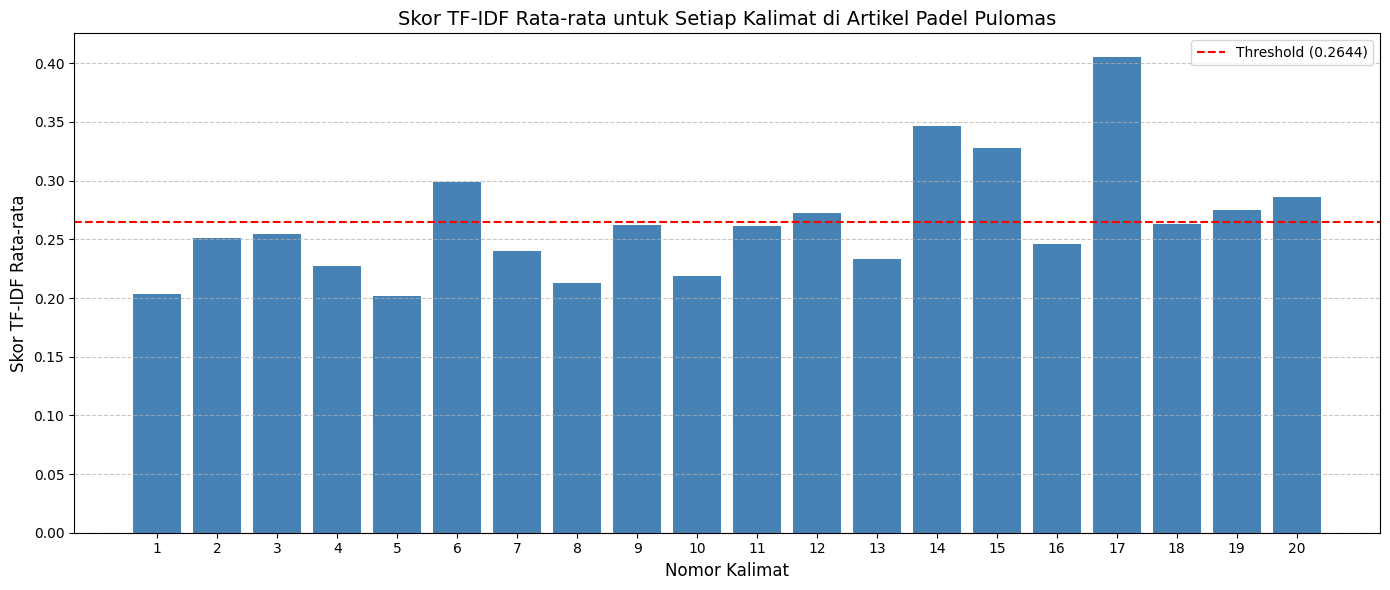


**Visualisasi:**
- Batang biru mewakili skor TF-IDF untuk setiap kalimat
- Garis merah putus-putus mewakili threshold (skor rata-rata)
- Kalimat di atas garis memiliki tingkat kepentingan lebih tinggi


In [5]:
# Visualisasikan skor TF-IDF rata-rata sebagai histogram
plt.figure(figsize=(14, 6))
plt.bar(range(1, len(sent_scores_padel) + 1), sent_scores_padel, color='steelblue')
plt.axhline(y=threshold_padel, color='r', linestyle='--', label=f'Threshold ({threshold_padel:.4f})')
plt.xlabel("Nomor Kalimat", fontsize=12)
plt.ylabel("Skor TF-IDF Rata-rata", fontsize=12)
plt.title("Skor TF-IDF Rata-rata untuk Setiap Kalimat di Artikel Padel Pulomas", fontsize=14)
plt.xticks(range(1, len(sent_scores_padel) + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Visualisasi:**")
print("- Batang biru mewakili skor TF-IDF untuk setiap kalimat")
print("- Garis merah putus-putus mewakili threshold (skor rata-rata)")
print("- Kalimat di atas garis memiliki tingkat kepentingan lebih tinggi")

## Top 5 Kata Penting per Kalimat

In [6]:
# Tampilkan 5 kata paling penting untuk setiap kalimat
print("\n**5 Kata Paling Penting (berdasarkan Skor TF-IDF) untuk Setiap Kalimat:**\n")

for sent_idx in range(features_padel.shape[0]):
    # Dapatkan skor TF-IDF untuk kalimat ini
    tfidf_scores = features_padel[sent_idx].toarray().flatten()
    
    # Dapatkan indeks dari 5 skor teratas
    top_indices = tfidf_scores.argsort()[-5:][::-1]
    
    print(f"Kalimat {sent_idx + 1}:")
    print(f"Teks: {sent_token_padel[sent_idx]}")
    print("5 Kata Teratas:")
    
    for rank, word_idx in enumerate(top_indices, 1):
        word = feature_names_padel[word_idx]
        score = tfidf_scores[word_idx]
        if score > 0:  # Hanya tampilkan skor non-nol
            print(f"  {rank}. '{word}': {score:.4f}")
    print()


**5 Kata Paling Penting (berdasarkan Skor TF-IDF) untuk Setiap Kalimat:**

Kalimat 1:
Teks: 
Kisruh Lapangan Padel Pulomas, Warga Menang Gugatan di PTUN

PENGADILAN Tinggi Tata Usaha Negara (PTUN) Jakarta mengabulkan seluruh permohonan warga Pulomas yang menolak keberadaan lapangan milik Star Padel.
5 Kata Teratas:
  1. 'pulomas': 0.3278
  2. 'ptun': 0.2778
  3. 'lapangan': 0.2778
  4. 'warga': 0.2278
  5. 'padel': 0.2148

Kalimat 2:
Teks: Lapangan padel itu digugat karena berada di tengah-tengah komplek pemukiman sehingga mengganggu kenyamanan warga.
5 Kata Teratas:
  1. 'tengah': 0.5378
  2. 'kenyamanan': 0.2689
  3. 'komplek': 0.2689
  4. 'mengganggu': 0.2689
  5. 'pemukiman': 0.2689

Kalimat 3:
Teks: Dalam putusannya, majelis hakim PTUN Jakarta menyatakan bahwa izin usaha Star Padel tersebut tidak sah.
5 Kata Teratas:
  1. 'putusannya': 0.3167
  2. 'bahwa': 0.3167
  3. 'dalam': 0.3167
  4. 'usaha': 0.2784
  5. 'sah': 0.2784

Kalimat 4:
Teks: "Mengabulkan gugatan para penggugat unt

## Ekstraksi Ringkasan

In [7]:
# Ekstrak ringkasan berdasarkan threshold
print("**Ekstraksi Ringkasan Berdasarkan Threshold**\n")
print(f"Threshold: {threshold_padel:.4f}\n")

final_summary_padel = ""
important_sentences = []

print("**Kalimat di atas threshold (kalimat penting untuk ringkasan):**\n")
for index, score in enumerate(sent_scores_padel):
    if score >= threshold_padel:
        important_sentences.append((index, sent_token_padel[index], score))
        final_summary_padel += " " + sent_token_padel[index]
        print(f"Kalimat {index + 1} (Skor: {score:.4f}):")
        print(f"  {sent_token_padel[index]}\n")

print("\n" + "="*80)
print("**RINGKASAN AKHIR ARTIKEL PADEL PULOMAS:**")
print("="*80)
print(final_summary_padel.strip())

**Ekstraksi Ringkasan Berdasarkan Threshold**

Threshold: 0.2644

**Kalimat di atas threshold (kalimat penting untuk ringkasan):**

Kalimat 6 (Skor: 0.2988):
  Oleh karena itu, hakim mewajibkan pemerintah untuk segera mencabut izin tersebut.

Kalimat 12 (Skor: 0.2728):
  Namun dari sejumlah pertemuan, pihak Star Padel selalu melanggar kesepakatan yang telah ditentukan.

Kalimat 14 (Skor: 0.3469):
  Akhirnya warga mendaftarkan gugatan PTUN pada Maret 2025.

Kalimat 15 (Skor: 0.3274):
  Zul menyatakan, warga merasa bersyukur gugatan mereka dikabulkan majelis.

Kalimat 17 (Skor: 0.4053):
  "Mereka menuntut balik, banding," ucap Zul.

Kalimat 19 (Skor: 0.2753):
  Namun petugas keamanan yang berjaga menghalangi dan melarang wartawan untuk mendekati area bangunan.

Kalimat 20 (Skor: 0.2859):
  "Intinya kalau operasional masih," kata petugas keamanan yang enggan disebutkan namanya tersebut.


**RINGKASAN AKHIR ARTIKEL PADEL PULOMAS:**
Oleh karena itu, hakim mewajibkan pemerintah untuk segera 

## Analisis Frekuensi Kata

**15 Kata Paling Sering Muncul di Artikel Padel:**

Peringkat Kata                 Frekuensi   
1        ,                    18          
2        .                    18          
3        padel                10          
4        warga                9           
5        lapangan             6           
6        gugatan              6           
7        tersebut             6           
8        ptun                 5           
9        jakarta              5           
10       yang                 5           
11       star                 5           
12       pulomas              4           
13       tidak                4           
14       ``                   4           
15       untuk                4           

**Frekuensi Kata Kunci:**
- 'padel' muncul: 10 kali
- 'warga' muncul: 9 kali
- 'gugatan' muncul: 6 kali
- 'ptun' muncul: 5 kali


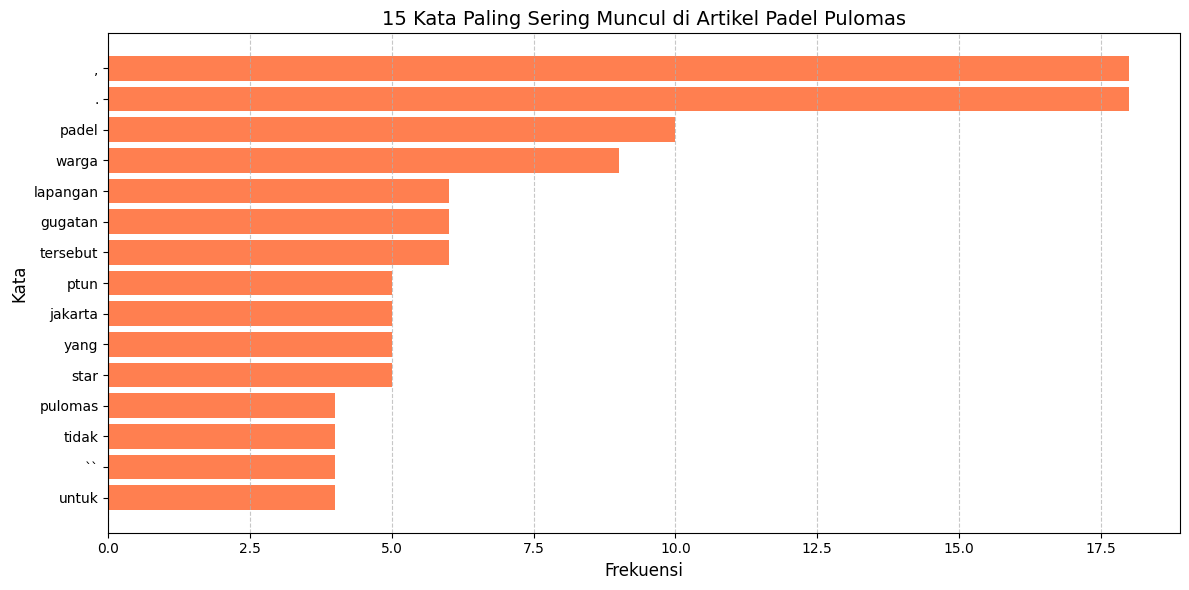


**Total kata unik**: 200
**Total kata keseluruhan**: 352


In [8]:
# Tokenisasi seluruh artikel dan ubah ke huruf kecil
all_words_padel = word_tokenize(artikel_padel.lower())

# Hitung frekuensi setiap kata
word_freq_padel = Counter(all_words_padel)

# Urutkan berdasarkan frekuensi (terbanyak dulu)
sorted_word_freq = sorted(word_freq_padel.items(), key=lambda x: x[1], reverse=True)

# Ambil top 15 kata
top_15_words = sorted_word_freq[:15]

print("**15 Kata Paling Sering Muncul di Artikel Padel:**\n")
print(f"{'Peringkat':<8} {'Kata':<20} {'Frekuensi':<12}")
print("="*40)

for rank, (word, freq) in enumerate(top_15_words, 1):
    print(f"{rank:<8} {word:<20} {freq:<12}")

# Hitung frekuensi kata kunci
padel_count = word_freq_padel.get('padel', 0)
warga_count = word_freq_padel.get('warga', 0)
gugatan_count = word_freq_padel.get('gugatan', 0)
ptun_count = word_freq_padel.get('ptun', 0)

print(f"\n**Frekuensi Kata Kunci:**")
print(f"- 'padel' muncul: {padel_count} kali")
print(f"- 'warga' muncul: {warga_count} kali")
print(f"- 'gugatan' muncul: {gugatan_count} kali")
print(f"- 'ptun' muncul: {ptun_count} kali")

# Visualisasi top 15 kata
words_list = [item[0] for item in top_15_words]
freq_list = [item[1] for item in top_15_words]

plt.figure(figsize=(12, 6))
plt.barh(words_list[::-1], freq_list[::-1], color='coral')
plt.xlabel('Frekuensi', fontsize=12)
plt.ylabel('Kata', fontsize=12)
plt.title('15 Kata Paling Sering Muncul di Artikel Padel Pulomas', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\n**Total kata unik**: {len(word_freq_padel)}")
print(f"**Total kata keseluruhan**: {len(all_words_padel)}")